# Indian Pines Hyperspectral Dataset Overview

This notebook introduces a simple and reproducible workflow for loading the Indian Pines hyperspectral dataset from MATLAB `.mat` files, inspecting its structure, summarizing the ground-truth labels, and visualizing both spectral data and the label map.

It assumes that `Indian_pines_corrected.mat` and `Indian_pines_gt.mat` are stored in the same directory as this notebook.

## 1. Import Required Libraries

We import the main scientific Python tools used in introductory hyperspectral analysis: `numpy` for array operations, `scipy.io` for reading MATLAB files, and `matplotlib` for visualization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import ListedColormap
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
}) 


CLASS_NAMES = {
    1: "Alfalfa",
    2: "Corn-notill",
    3: "Corn-mintill",
    4: "Corn",
    5: "Grass-pasture",
    6: "Grass-trees",
    7: "Grass-pasture-mowed",
    8: "Hay-windrowed",
    9: "Oats",
    10: "Soybean-notill",
    11: "Soybean-mintill",
    12: "Soybean-clean",
    13: "Wheat",
    14: "Woods",
    15: "Buildings-Grass-Trees-Drives",
    16: "Stone-Steel-Towers",
}

# Crop-specific color families for clearer within-family comparisons.
SIGNATURE_PALETTE = {
    2: "#E67E22",   # Corn-notill: orange
    3: "#F1C40F",   # Corn-mintill: yellow
    4: "#B7950B",   # Corn: gold
    10: "#1F77B4",  # Soybean-notill: blue
    11: "#2CA02C",  # Soybean-mintill: green
    12: "#17BECF",  # Soybean-clean: cyan
}

CORN_CLASS_IDS = [2, 3, 4]
SOY_CLASS_IDS = [10, 11, 12]
SPECTRAL_REGIONS = [
    (0.4, 0.7, "Visible", "#FDE68A"),
    (0.7, 1.3, "NIR", "#BFDBFE"),
    (1.3, 2.5, "SWIR", "#D8B4FE"),
]
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

REDUCED_PCA_PALETTE = {
    2: "#E41A1C",   # red
    3: "#377EB8",   # blue
    4: "#4DAF4A",   # green
    10: "#FF7F00",  # orange
    11: "#984EA3",  # purple
    12: "#A65628",  # brown
}

## 2. Load the Dataset Files

The helper function below reads a `.mat` file and extracts the main array while ignoring MATLAB metadata fields such as `__header__` and `__globals__`.

In [2]:
def load_single_mat_array(mat_data, mat_path: Path):
    """Load the main array from a MATLAB .mat file dictionary."""
    candidate_keys = [key for key in mat_data.keys() if not key.startswith("__")]

    if not candidate_keys:
        raise ValueError(f"No data arrays found in {mat_path.name}")

    # Prefer the first non-empty ndarray entry.
    for key in candidate_keys:
        value = mat_data[key]
        if isinstance(value, np.ndarray) and value.size > 0:
            return key, value

    raise ValueError(f"Could not locate a valid ndarray in {mat_path.name}")


data_path = Path("Indian_pines_corrected.mat")
gt_path = Path("Indian_pines_gt.mat")

def find_wavelength_vector(*mat_dicts, expected_bands: int | None = None):
    """Try to locate a wavelength vector from loaded MATLAB dictionaries."""
    key_hints = ("wavelength", "wavelengths", "bands", "band_centers", "lambda", "wvl")

    for mat_dict in mat_dicts:
        for key, value in mat_dict.items():
            if key.startswith("__") or not isinstance(value, np.ndarray):
                continue

            flattened = np.squeeze(value)
            if flattened.ndim != 1:
                continue
            if expected_bands is not None and flattened.size != expected_bands:
                continue
            if not np.issubdtype(flattened.dtype, np.number):
                continue
            if not any(hint in key.lower() for hint in key_hints):
                continue

            return key, flattened.astype(np.float32)

    return None, None


data_mat = loadmat(data_path)
gt_mat = loadmat(gt_path)

data_key, data_cube = load_single_mat_array(data_mat, data_path)
gt_key, ground_truth = load_single_mat_array(gt_mat, gt_path)
wavelength_key, band_wavelengths = find_wavelength_vector(data_mat, gt_mat, expected_bands=data_cube.shape[2])

# If exact band centers are unavailable, estimate an approximate wavelength axis.
# Indian Pines is commonly described as spanning 0.4 to 2.5 micrometers.
if band_wavelengths is None:
    band_wavelengths = np.linspace(0.4, 2.5, data_cube.shape[2], dtype=np.float32)
    wavelength_key = "estimated_linear_spacing_0.4_to_2.5_um"

print(f"Loaded spectral cube from: {data_path.name} -> key '{data_key}'")
print(f"Loaded ground-truth map from: {gt_path.name} -> key '{gt_key}'")
print(f"Using wavelength vector from '{wavelength_key}' with {band_wavelengths.size} entries")

Loaded spectral cube from: Indian_pines_corrected.mat -> key 'indian_pines_corrected'
Loaded ground-truth map from: Indian_pines_gt.mat -> key 'indian_pines_gt'
No wavelength vector was found in the provided .mat files; plots will fall back to band index when needed.


## 3. Inspect Basic Dataset Metadata

Hyperspectral images are typically represented as a 3D data cube with dimensions `(height, width, spectral_bands)`. The following cell reports the main structural and memory-related properties of the dataset.

In [3]:
def format_bytes(num_bytes: int) -> str:
    """Convert a byte count to a human-readable string."""
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024


height, width, num_bands = data_cube.shape
num_pixels = height * width
memory_size_bytes = data_cube.nbytes

print("Dataset Metadata")
print("-" * 60)
print(f"Dimensions (H x W x Bands): {height} x {width} x {num_bands}")
print(f"Data type: {data_cube.dtype}")
print(f"Number of pixels: {num_pixels:,}")
print(f"Number of spectral bands: {num_bands}")
print(f"Memory size: {memory_size_bytes:,} bytes ({format_bytes(memory_size_bytes)})")

Dataset Metadata
------------------------------------------------------------
Dimensions (H x W x Bands): 145 x 145 x 200
Data type: uint16
Number of pixels: 21,025
Number of spectral bands: 200
Memory size: 8,410,000 bytes (8.02 MB)


## 4. Inspect the Ground-Truth Labels

The Indian Pines ground-truth map is a 2D label image. Label `0` usually represents background or unlabeled pixels, so we exclude it when counting semantic classes.

In [4]:
unique_labels, label_counts = np.unique(ground_truth, return_counts=True)
class_mask = unique_labels != 0
class_labels = unique_labels[class_mask]
class_counts = label_counts[class_mask]

print("Ground-Truth Metadata")
print("-" * 60)
print(f"Ground-truth shape: {ground_truth.shape}")
print(f"Number of classes (excluding background): {len(class_labels)}")
print("Pixel count per class:")

for class_id, count in zip(class_labels, class_counts):
    class_id = int(class_id)
    class_name = CLASS_NAMES.get(class_id, f"Class {class_id}")
    print(f"  {class_id:2d} - {class_name}: {int(count):,} pixels")

Ground-Truth Metadata
------------------------------------------------------------
Ground-truth shape: (145, 145)
Number of classes (excluding background): 16
Pixel count per class:
   1 - Alfalfa: 46 pixels
   2 - Corn-notill: 1,428 pixels
   3 - Corn-mintill: 830 pixels
   4 - Corn: 237 pixels
   5 - Grass-pasture: 483 pixels
   6 - Grass-trees: 730 pixels
   7 - Grass-pasture-mowed: 28 pixels
   8 - Hay-windrowed: 478 pixels
   9 - Oats: 20 pixels
  10 - Soybean-notill: 972 pixels
  11 - Soybean-mintill: 2,455 pixels
  12 - Soybean-clean: 593 pixels
  13 - Wheat: 205 pixels
  14 - Woods: 1,265 pixels
  15 - Buildings-Grass-Trees-Drives: 386 pixels
  16 - Stone-Steel-Towers: 93 pixels


## 5. Print a Concise Dataset Summary

This short summary combines the most important structural information about the spectral cube and its annotation map.

In [5]:
labeled_pixels = int(class_counts.sum())
background_pixels = int(label_counts[unique_labels == 0][0]) if np.any(unique_labels == 0) else 0
labeled_ratio = labeled_pixels / num_pixels

summary = (
    f"The Indian Pines spectral cube contains {height} rows, {width} columns, and {num_bands} spectral bands. "
    f"In total, it stores {num_pixels:,} pixels using the {data_cube.dtype} data type, occupying "
    f"{format_bytes(memory_size_bytes)} in memory. The ground-truth map has {len(class_labels)} labeled classes "
    f"plus background, with {labeled_pixels:,} labeled pixels ({labeled_ratio:.2%}) and {background_pixels:,} background pixels."
)

print(summary)

The Indian Pines spectral cube contains 145 rows, 145 columns, and 200 spectral bands. In total, it stores 21,025 pixels using the uint16 data type, occupying 8.02 MB in memory. The ground-truth map has 16 labeled classes plus background, with 10,249 labeled pixels (48.75%) and 10,776 background pixels.


## 6. Visualize a Single Spectral Band and the Ground-Truth Label Map

A hyperspectral cube can be explored band by band. Below, we display one spectral band as a grayscale image and the label map with a categorical color legend.

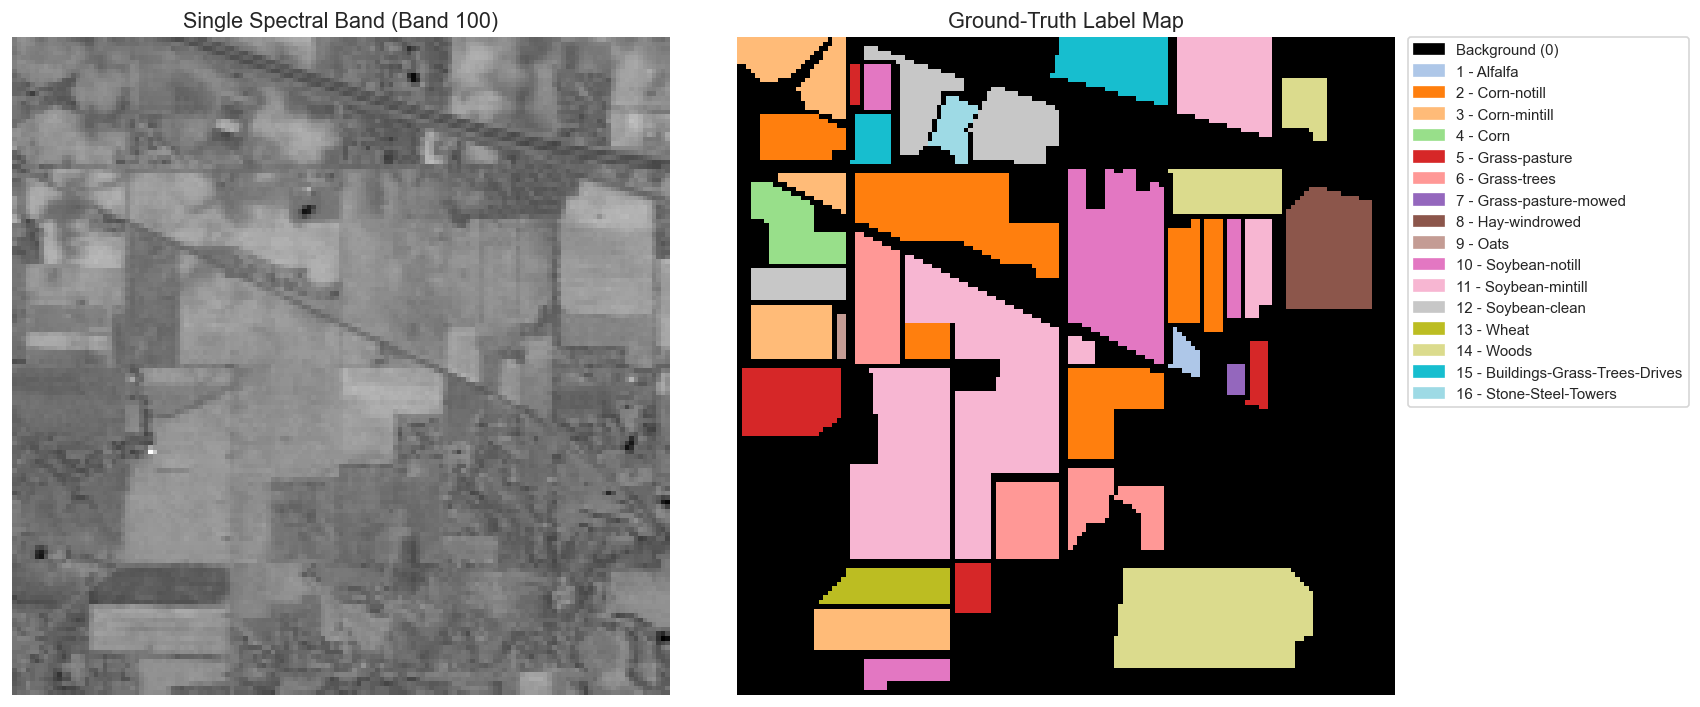

In [6]:
# Use the middle spectral band for a simple grayscale preview.
band_index = num_bands // 2
single_band = data_cube[:, :, band_index]

# Build a discrete colormap: background in black, classes in tab20 colors.
max_label = int(ground_truth.max())
base_colors = plt.cm.tab20(np.linspace(0, 1, max(max_label, 1) + 1))
base_colors[0] = np.array([0, 0, 0, 1])
label_cmap = ListedColormap(base_colors)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(single_band, cmap="gray")
axes[0].set_title(f"Single Spectral Band (Band {band_index})")
axes[0].axis("off")

im = axes[1].imshow(ground_truth, cmap=label_cmap, vmin=0, vmax=max_label)
axes[1].set_title("Ground-Truth Label Map")
axes[1].axis("off")

legend_handles = [patches.Patch(color=base_colors[0], label="Background (0)")]
legend_handles.extend(
    patches.Patch(
        color=base_colors[int(class_id)],
        label=f"{int(class_id)} - {CLASS_NAMES.get(int(class_id), f'Class {int(class_id)}')}"
    )
    for class_id in class_labels
)

axes[1].legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
)

plt.tight_layout()
plt.show()

## 7. Visualization 1: Average Spectral Signatures for Corn and Soybean Management Classes

A useful first hyperspectral visualization is the average spectral signature of selected classes. Here we focus on six closely related agricultural classes so we can compare how management technique affects spectral behavior within corn and soybean crops: `Corn-notill`, `Corn-mintill`, `Corn`, `Soybean-notill`, `Soybean-mintill`, and `Soybean-clean`.

For each class, we extract all labeled pixels, compute the mean reflectance profile across the 200 spectral bands, and summarize variability with the standard deviation. To make the comparison cleaner, the notebook produces two separate figures: one for the three corn management classes and one for the three soybean management classes. It also adds companion difference plots that show pairwise mean-signature gaps within each crop family.

The x-axis uses wavelength in micrometers. When exact band centers are unavailable in the `.mat` files, the notebook estimates them by linearly spacing the 200 corrected bands across the commonly reported Indian Pines range of `0.4` to `2.5 um`. The figures also shade the broad spectral regions `Visible (0.4-0.7 um)`, `NIR (0.7-1.3 um)`, and `SWIR (>1.3 um)`, and the notebook exports standalone PNG files plus side-by-side paired layouts for corn and soybean.

In [7]:
REPRESENTATIVE_CLASS_IDS = [2, 3, 4, 10, 11, 12]

spectral_stats = {}
for class_id in REPRESENTATIVE_CLASS_IDS:
    class_mask = ground_truth == class_id
    class_pixels = data_cube[class_mask].astype(np.float32)

    spectral_stats[class_id] = {
        "name": CLASS_NAMES[class_id],
        "count": class_pixels.shape[0],
        "mean": class_pixels.mean(axis=0),
        "std": class_pixels.std(axis=0),
    }

spectral_summary_df = pd.DataFrame(
    {
        "class_id": class_id,
        "class_name": stats["name"],
        "pixel_count": stats["count"],
    }
    for class_id, stats in spectral_stats.items()
).sort_values("class_id")

spectral_summary_df

,class_id,class_name,pixel_count
0,2,Corn-notill,1428
1,3,Corn-mintill,830
2,4,Corn,237
3,10,Soybean-notill,972
4,11,Soybean-mintill,2455
5,12,Soybean-clean,593


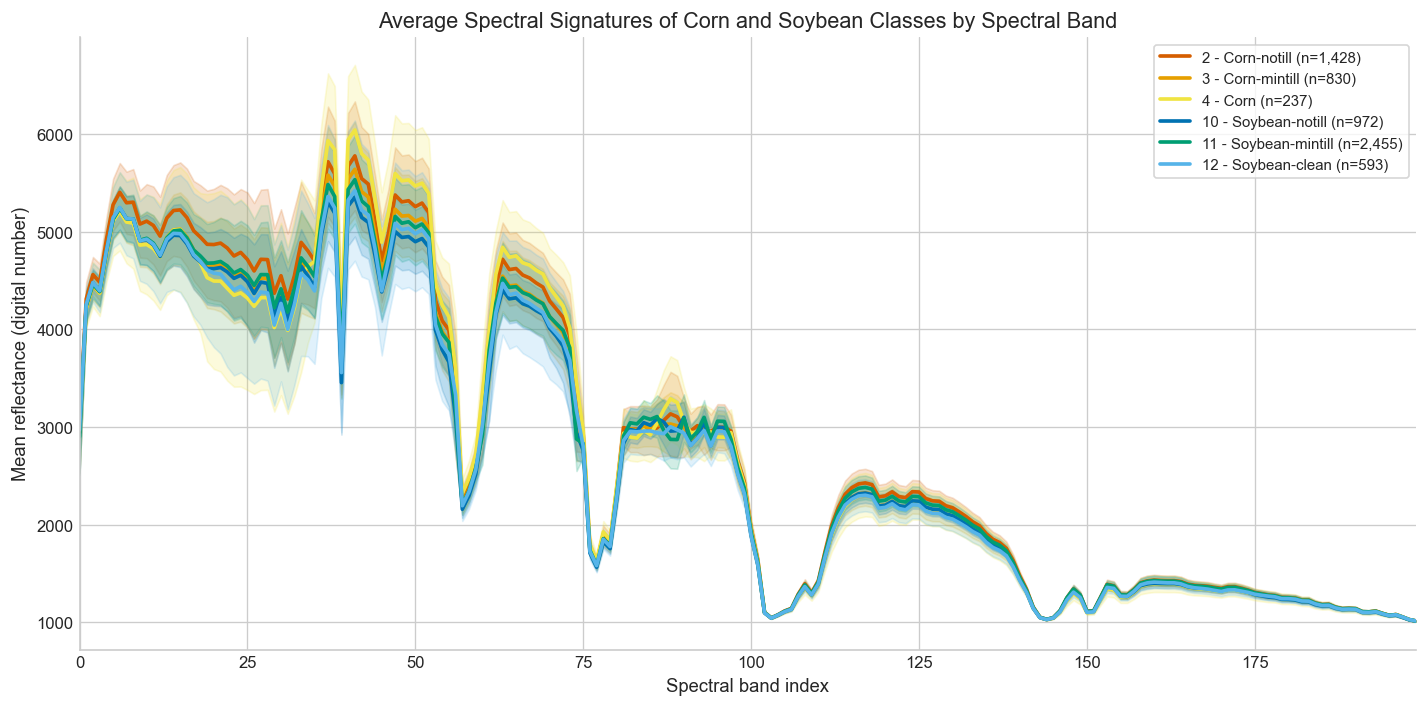

In [8]:
from itertools import combinations

x_values = band_wavelengths
x_label = "Wavelength (um)"
xticks = np.arange(0.4, 2.51, 0.2)
exported_signature_figures = {}

def add_spectral_region_shading(ax):
    for start, end, label, color in SPECTRAL_REGIONS:
        ax.axvspan(start, end, color=color, alpha=0.12, zorder=0)
        ax.text(
            (start + end) / 2,
            0.98,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            weight="bold",
            color="#374151",
        )

def style_signature_axis(ax, title, ylabel):
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(ylabel)
    ax.set_xlim(x_values.min(), x_values.max())
    ax.set_xticks(xticks)
    ax.spines[["top", "right"]].set_visible(False)

def save_figure(fig, filename):
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return output_path

def plot_signature_family(class_ids, family_name, ax=None):
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure

    add_spectral_region_shading(ax)

    for class_id in class_ids:
        stats = spectral_stats[class_id]
        mean_signature = stats["mean"]
        std_signature = stats["std"]
        color = SIGNATURE_PALETTE[class_id]
        label = f"{stats['name']} (n={stats['count']:,})"

        ax.plot(x_values, mean_signature, color=color, linewidth=2.6, label=label, zorder=3)
        ax.fill_between(
            x_values,
            mean_signature - std_signature,
            mean_signature + std_signature,
            color=color,
            alpha=0.05,
            zorder=2,
        )

    style_signature_axis(
        ax,
        title=f"Average Spectral Signatures of {family_name} Management Classes",
        ylabel="Mean reflectance (digital number)",
    )
    ax.legend(loc="upper right", frameon=True)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax

def plot_difference_family(class_ids, family_name, ax=None):
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure

    add_spectral_region_shading(ax)
    pair_ids = list(combinations(class_ids, 2))

    for pair_index, (class_a, class_b) in enumerate(pair_ids):
        mean_a = spectral_stats[class_a]["mean"]
        mean_b = spectral_stats[class_b]["mean"]
        difference = mean_a - mean_b
        color = SIGNATURE_PALETTE[class_ids[pair_index]]
        label = f"{CLASS_NAMES[class_a]} - {CLASS_NAMES[class_b]}"
        ax.plot(x_values, difference, color=color, linewidth=2.4, label=label, zorder=3)

    ax.axhline(0.0, color="#4B5563", linewidth=1.2, linestyle="--", zorder=1)
    style_signature_axis(
        ax,
        title=f"Pairwise Mean-Signature Differences for {family_name} Variants",
        ylabel="Reflectance difference (digital number)",
    )
    ax.legend(loc="upper right", frameon=True)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax

def plot_family_pair(class_ids, family_name):
    fig, axes = plt.subplots(1, 2, figsize=(17, 6.2))
    plot_signature_family(class_ids, family_name, ax=axes[0])
    plot_difference_family(class_ids, family_name, ax=axes[1])
    fig.tight_layout()
    plt.show()
    return fig

family_configs = [
    (CORN_CLASS_IDS, "Corn", "corn"),
    (SOY_CLASS_IDS, "Soybean", "soybean"),
]

for class_ids, family_name, slug in family_configs:
    fig, _ = plot_signature_family(class_ids, family_name)
    exported_signature_figures[f"{slug}_signature"] = save_figure(fig, f"{slug}_spectral_signatures.png")
    plt.close(fig)

    fig, _ = plot_difference_family(class_ids, family_name)
    exported_signature_figures[f"{slug}_difference"] = save_figure(fig, f"{slug}_spectral_differences.png")
    plt.close(fig)

    fig = plot_family_pair(class_ids, family_name)
    exported_signature_figures[f"{slug}_pair"] = save_figure(fig, f"{slug}_signature_difference_pair.png")
    plt.close(fig)

pd.Series({key: str(path) for key, path in exported_signature_figures.items()}, name="saved_png")

### Interpretation of the Spectral Signatures

Separating the spectral-signature comparison into one corn figure and one soybean figure makes the within-family differences easier to read. The orange-yellow-gold corn palette and the blue-green-cyan soybean palette reinforce that grouping visually, while local deviations still reveal the influence of management practice, residue cover, canopy density, and exposed soil.

The shaded `Visible`, `NIR`, and `SWIR` regions help organize that comparison. Differences in the visible range are often related to pigment response, while variation in the near-infrared and shortwave-infrared ranges can reflect canopy structure, moisture, and background material. The pairwise difference plots make these gaps easier to inspect directly, because they center the comparison around zero and emphasize where one management variant rises above or falls below another.

This is why hyperspectral imagery is valuable for vegetation analysis: crops that may look very similar in a single grayscale or RGB-style view can still be distinguished by subtle but consistent differences across their full reflectance curves.

## 8. Visualization 2: Focused PCA Scatter for the Crop-Management Classes

This scatter plot uses the same six corn and soybean management classes from the spectral-signature comparison. By restricting the projection to these similar agricultural categories, the PCA view becomes more useful for studying whether cultivation technique leaves a measurable spectral pattern.

We reshape the hyperspectral cube into a pixel-by-band matrix, remove background pixels, keep only the selected crop-management classes, standardize the spectral values, and compute a two-dimensional PCA projection.

In [9]:
# Convert the hyperspectral cube into a 2D matrix: one row per pixel, one column per band.
pixel_matrix = data_cube.reshape(-1, num_bands).astype(np.float32)
label_vector = ground_truth.reshape(-1).astype(int)

# Remove background pixels so the analysis focuses only on labeled crop pixels.
labeled_mask = label_vector > 0
X_labeled = pixel_matrix[labeled_mask]
y_labeled = label_vector[labeled_mask]

# Keep only the six corn and soybean management classes used in the spectral-signature plot.
focused_class_ids = REPRESENTATIVE_CLASS_IDS
focused_mask = np.isin(y_labeled, focused_class_ids)
X_focused = X_labeled[focused_mask]
y_focused = y_labeled[focused_mask]

# Sample up to 6,000 pixels so the scatter plot remains readable and reproducible.
max_samples = 6_000
rng = np.random.default_rng(42)
sample_size = min(max_samples, X_focused.shape[0])
sample_indices = rng.choice(X_focused.shape[0], size=sample_size, replace=False)

X_sample = X_focused[sample_indices]
y_sample = y_focused[sample_indices]

# Standardize spectral bands before PCA so no band dominates only because of scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

projection_summary_df = pd.DataFrame(
    {
        "class_id": np.sort(np.unique(y_sample)),
        "class_name": [CLASS_NAMES[class_id] for class_id in np.sort(np.unique(y_sample))],
        "sampled_pixels": [int(np.sum(y_sample == class_id)) for class_id in np.sort(np.unique(y_sample))],
    }
)

print(f"Focused labeled pixels available: {X_focused.shape[0]:,}")
print(f"Pixels used in focused PCA visualization: {sample_size:,}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_[0]:.2%}, {pca.explained_variance_ratio_[1]:.2%}")
projection_summary_df

Focused labeled pixels available: 6,515
Pixels used in focused PCA visualization: 6,000
PCA explained variance ratio: 73.23%, 9.38%


,class_id,class_name,sampled_pixels
0,2,Corn-notill,1298
1,3,Corn-mintill,766
2,4,Corn,220
3,10,Soybean-notill,888
4,11,Soybean-mintill,2275
5,12,Soybean-clean,553


### Interpretation of the Focused PCA Scatter

Because this PCA uses only the six corn and soybean management classes, the scatter emphasizes subtle differences within two very similar crop families instead of broader land-cover differences. Some overlap is expected, especially among variants of the same plant type, because tillage and cleaning technique do not change the underlying vegetation as dramatically as switching to a different crop type.

Even so, if the corn classes or soybean classes begin to occupy slightly different regions of the PCA plane, that suggests the spectral information still captures management-related effects such as residue cover, canopy development, or exposed soil contribution.

This focused scatter is therefore a compact way to check whether similar crops under different cultivation techniques are only weakly separable or whether they already show meaningful structure in a simple linear projection.

## 10. Key Insights Summary

- The average spectral signature plots highlight how the corn and soybean management variants differ across the 200 spectral bands, while also revealing where related cultivars still overlap.
- The shaded standard deviation regions show within-class variability, which is important when judging whether two categories are likely to be confused.
- The spectral-signature analysis separates corn and soybean into two figures, uses distinct crop-specific color families, and adds pairwise difference plots that make subtle within-family gaps easier to read across the visible, NIR, and SWIR wavelength regions.
- The focused PCA scatter shows how the same six corn and soybean management classes occupy a shared spectral space once unrelated land-cover classes are removed from the comparison.
- The centroid-enhanced PCA view makes it easier to judge average class separation and within-class spread for these similar crop-management categories.
- Taken together, these visualizations show why hyperspectral imagery is effective for crop analysis: visually similar classes can still be separated using their richer spectral behavior.